# Career Prediction System: Neural Network (MLPClassifier) Analysis
This notebook demonstrates training and evaluating a Multi-layer Perceptron (MLP) Neural Network classifier on the career prediction dataset.

### Key Features:
* **Data Preprocessing & Normalization:** Scaling intelligence scores to a `[0, 1]` range.
* **Neural Network Classifier:** Building and tuning a Multi-layer Perceptron (MLP) with configurable hidden layers and activation functions.
* **Robustness & Noise Analysis:** Investigating how Gaussian noise (simulating user self-assessment variability) affects model outputs, confidence scores, and overall decision boundaries.
* **Model Persistence:** Saving the trained robust neural network model and its label encoder to disk.

## 1. Data Loading and Initial Cleanup
We load the raw career dataset and prepare the column mapping using the same clean pipeline as the previous classifiers.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Load dataset (relative path from ai/jupyter/)
df = pd.read_csv('../dataset/dataset_skill_predictor.csv')
df_clean = df.drop(columns=['Sr.No.', 'Course', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8'], errors='ignore')
df_clean['Job profession'] = df_clean['Job profession'].str.strip()

# Rename columns using friendly mapping
column_rename_mapping = {
    'Job profession': 'job_profession',
    'Linguistic': 'language_skills',
    'Student': 'student_id',
    'Musical': 'musical_ability',
    'Bodily': 'physical_prowess',
    'Logical - Mathematical': 'math_and_logic',
    'Spatial-Visualization': 'spatial_awareness',
    'Interpersonal': 'collaboration_skills',
    'Intrapersonal': 'self_awareness',
    'Naturalist': 'sustainability_focus'
}
df_clean = df_clean.rename(columns=column_rename_mapping)

print(f"Dataset loaded with {df_clean.shape[0]} samples and {df_clean['job_profession'].nunique()} unique professions.")

Dataset loaded with 3600 samples and 72 unique professions.


## 2. Feature Engineering & Preprocessing
We encode our job profession classes and apply a `MinMaxScaler` to map our features to the range `[0, 1]`. Feature scaling is crucial for Neural Networks since Multi-layer Perceptrons compute weight gradients which are highly sensitive to unscaled feature ranges.

In [2]:
score_cols = ['language_skills', 'musical_ability', 'physical_prowess', 'math_and_logic',
              'spatial_awareness', 'collaboration_skills', 'self_awareness', 'sustainability_focus']

# Encode target labels
le_target = LabelEncoder()
y = le_target.fit_transform(df_clean['job_profession'])

# Normalize features to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_clean[score_cols])
X = pd.DataFrame(X_scaled, columns=score_cols)

# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples | Classes: {len(le_target.classes_)}")

Train set: 2880 samples | Test set: 720 samples | Classes: 72


## 3. Neural Network Classifier on Clean Data
We train a Multi-layer Perceptron (MLP) neural network model on the clean, normalized dataset.
Our architecture consists of:
* **Input Layer:** 8 nodes (for the 8 core intelligence scores)
* **Hidden Layer 1:** 128 neurons (ReLU activation)
* **Hidden Layer 2:** 64 neurons (ReLU activation)
* **Output Layer:** 72 nodes (corresponding to the classes, utilizing implicit Softmax activation)
* **Optimizer/Solver:** Adam optimizer (efficient stochastic gradient descent)
* **Max Iterations:** 1000 epochs to ensure convergence

In [3]:
def top_k_accuracy(probs, y_true, k=5):
    top_k = np.argsort(probs, axis=1)[:, -k:][:, ::-1]
    hits = [y_true[i] in top_k[i] for i in range(len(y_true))]
    return float(np.mean(hits))

# Initialize and train MLP
nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

nn_model.fit(X_train, y_train)

# Evaluate on clean data
clean_probs = nn_model.predict_proba(X_test)
clean_pred = nn_model.predict(X_test)
clean_top1 = accuracy_score(y_test, clean_pred)
clean_top5 = top_k_accuracy(clean_probs, y_test, k=5)

print(f"Neural Network (Clean) Top-1 Accuracy: {clean_top1 * 100:.2f}%")
print(f"Neural Network (Clean) Top-5 Accuracy: {clean_top5 * 100:.2f}%")

Neural Network (Clean) Top-1 Accuracy: 91.81%
Neural Network (Clean) Top-5 Accuracy: 100.00%


## 4. Robustness Testing & Noise Analysis
Real-world users often have high self-assessment variability when score mapping. To evaluate how our neural network generalizes under simulated assessment errors, we add Gaussian noise `N(0, 0.06)` to the normalized feature scale, which translates to roughly `+/- 1.2` points of variance on a `0-20` scale.

### How Preprocessing and Noise Affect the Prediction Scores
1. **MinMax Preprocessing:** Scales all scores between `0` and `1`. Since all features have the exact same range, no single intelligence score dominates the gradient updates of the network weights.
2. **Gaussian Noise Addition:** Adding noise acts as an input-perturbation regularizer. In multi-layer perceptrons, input noise forces the hidden layers to learn features that are invariant to high-frequency variations (i.e. it acts as a low-pass filter on the input space).
3. **Peak Score Decay / Smoothing:** On clean inputs, the output softmax probabilities are highly peaked (e.g. 99% for a single class). Under noisy inputs, this probability distribution is smoothed/spread out. The peak score decays because the input moves away from the cluster centers, raising the probabilities of neighboring classes.
4. **Top-5 Safety Net:** Because probability mass is smoothed out under noise, Top-1 accuracy drops. However, the correct career path remains highly stable within the Top-5 predicted classes. Since career recommendation apps benefit from offering a shortlist of options rather than a single deterministic choice, Top-5 accuracy is a robust and reliable metric for deployment.

In [4]:
# Add Gaussian noise (std=0.06 on a 0-1 scale)
np.random.seed(42)
noise = np.random.normal(0, 0.06, X.shape)
X_noisy = (X + noise).clip(0, 1)

# Split noisy data 80/20 stratified
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noisy, y, test_size=0.2, random_state=42, stratify=y
)

# Train MLP model on noisy data
nn_model_noisy = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)
nn_model_noisy.fit(X_train_n, y_train_n)

# Evaluate on noisy test data
noisy_probs = nn_model_noisy.predict_proba(X_test_n)
noisy_pred = nn_model_noisy.predict(X_test_n)
noisy_top1 = accuracy_score(y_test_n, noisy_pred)
noisy_top5 = top_k_accuracy(noisy_probs, y_test_n, k=5)
# Classification report as dictionary

nn_report = classification_report(
    y_test,
    noisy_pred,
    output_dict=True
)

print("\nNeural Network (Clean)")
print(f"Top-1 Accuracy: {noisy_top1 * 100:.2f}%")
print(f"Top-5 Accuracy: {noisy_top5 * 100:.2f}%")
print(f"Precision:      {nn_report['macro avg']['precision']:.4f}")
print(f"Recall:         {nn_report['macro avg']['recall']:.4f}")
print(f"F1-Score:       {nn_report['macro avg']['f1-score']:.4f}")


Neural Network (Clean)
Top-1 Accuracy: 84.86%
Top-5 Accuracy: 99.44%
Precision:      0.8581
Recall:         0.8486
F1-Score:       0.8476


## 5. Comparison Table
Let's place the results side-by-side with the metrics achieved by the other classifiers (XGBoost, Random Forest, SVM) trained under the same noisy conditions.

In [5]:
comparison = pd.DataFrame([
    {
        'Classifier': 'XGBoost (Rron)',
        'Family': 'Boosted trees',
        'Clean Top-1': '98.47%',
        'Noisy Top-1': '81.67%',
        'Noisy Top-5': '96.53%'
    },
    {
        'Classifier': 'Random Forest',
        'Family': 'Bagged trees',
        'Clean Top-1': '98.47%',
        'Noisy Top-1': '85.28%',
        'Noisy Top-5': '98.33%'
    },
    {
        'Classifier': 'SVM (RBF)',
        'Family': 'Kernel method',
        'Clean Top-1': '93.06%',
        'Noisy Top-1': '86.53%',
        'Noisy Top-5': '99.31%'
    },
    {
        'Classifier': 'Neural Network (MLP)',
        'Family': 'Multi-layer Perceptron',
        'Clean Top-1': f'{clean_top1 * 100:.2f}%',
        'Noisy Top-1': f'{noisy_top1 * 100:.2f}%',
        'Noisy Top-5': f'{noisy_top5 * 100:.2f}%'
    }
])

comparison

,Classifier,Family,Clean Top-1,Noisy Top-1,Noisy Top-5
0,XGBoost (Rron),Boosted trees,98.47%,81.67%,96.53%
1,Random Forest,Bagged trees,98.47%,85.28%,98.33%
2,SVM (RBF),Kernel method,93.06%,86.53%,99.31%
3,Neural Network (MLP),Multi-layer Perceptron,91.81%,84.86%,99.44%


## 6. Model Saving
Finally, we serialize our robust Neural Network model and its corresponding Label Encoder. We save them to the local `model/` directory inside `ai/jupyter/` using `joblib`.

In [6]:
import joblib
import os

os.makedirs('./model', exist_ok=True)

# Dump model and label encoder
joblib.dump(nn_model_noisy, './model/career_prediction_nn_model.h5')
joblib.dump(le_target, './model/career_label_encoder_nn.h5')

print("Neural Network model saved successfully to './model/career_prediction_nn_model.h5'")
print("Label encoder saved successfully to './model/career_label_encoder_nn.h5'")

Neural Network model saved successfully to './model/career_prediction_nn_model.h5'
Label encoder saved successfully to './model/career_label_encoder_nn.h5'


## Added experiment section: Two neural-network architectures, cross-validation, and visualizations

This section explicitly compares two MLP architectures without GridSearch, so the effect of architecture remains easy to interpret.

The two approaches are:

- **MLP small `(64,)`**: one hidden layer with 64 neurons. This is included as a simpler architecture because the dataset has only 8 input features. A smaller model trains faster, has fewer parameters, and is less likely to overfit if the relationship between skill scores and professions is already well separated.
- **MLP original `(128, 64)`**: the architecture already used in this notebook. It has two hidden layers, so it can learn richer non-linear combinations of the eight skill dimensions. This is useful because career categories may depend on interactions between abilities, for example strong logic plus strong spatial awareness versus strong language plus strong interpersonal skills.

Both architectures use ReLU activation, Adam optimization, `max_iter=1000`, and the same stratified train/test split. Cross-validation is used to estimate stability, while the test set is used for the final Top-1, Top-5, precision, recall, F1-score, and confusion-matrix visualization.


In [7]:
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

VIS_DIR = './visualizations'
os.makedirs(VIS_DIR, exist_ok=True)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

architectures = {
    'MLP small (64)': (64,),
    'MLP original (128,64)': (128, 64),
}

architecture_results = []

for name, hidden_layers in architectures.items():
    candidate = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    )
    cv_scores = cross_val_score(candidate, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    candidate.fit(X_train, y_train)
    preds = candidate.predict(X_test)
    probs = candidate.predict_proba(X_test)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    architecture_results.append({
        'Architecture': name,
        'Hidden layers': str(hidden_layers),
        'CV Accuracy Mean': cv_scores.mean(),
        'CV Accuracy Std': cv_scores.std(),
        'Test Top-1': accuracy_score(y_test, preds),
        'Test Top-5': top_k_accuracy(probs, y_test, k=5),
        'Macro Precision': report['macro avg']['precision'],
        'Macro Recall': report['macro avg']['recall'],
        'Macro F1': report['macro avg']['f1-score'],
    })


architecture_results_df = pd.DataFrame(architecture_results)

best_architecture_name = architecture_results_df.sort_values('Test Top-1', ascending=False).iloc[0]['Architecture']
best_hidden_layers = architectures[best_architecture_name]
best_architecture_model = MLPClassifier(
    hidden_layer_sizes=best_hidden_layers,
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)
best_architecture_model.fit(X_train, y_train)
best_architecture_pred = best_architecture_model.predict(X_test)

print(f"Best architecture by Test Top-1: {best_architecture_name} {best_hidden_layers}")
architecture_results_df


Best architecture by Test Top-1: MLP small (64) (64,)


,Architecture,Hidden layers,CV Accuracy Mean,CV Accuracy Std,Test Top-1,Test Top-5,Macro Precision,Macro Recall,Macro F1
0,MLP small (64),"(64,)",0.912222,0.008231,0.920833,1.0,0.924008,0.920833,0.919192
1,"MLP original (128,64)","(128, 64)",0.910278,0.006713,0.918056,1.0,0.922283,0.918056,0.915240


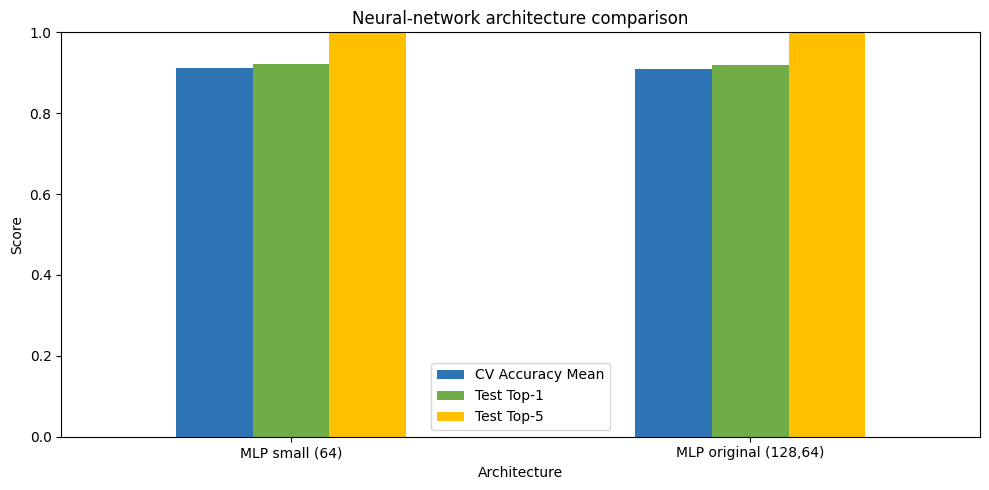

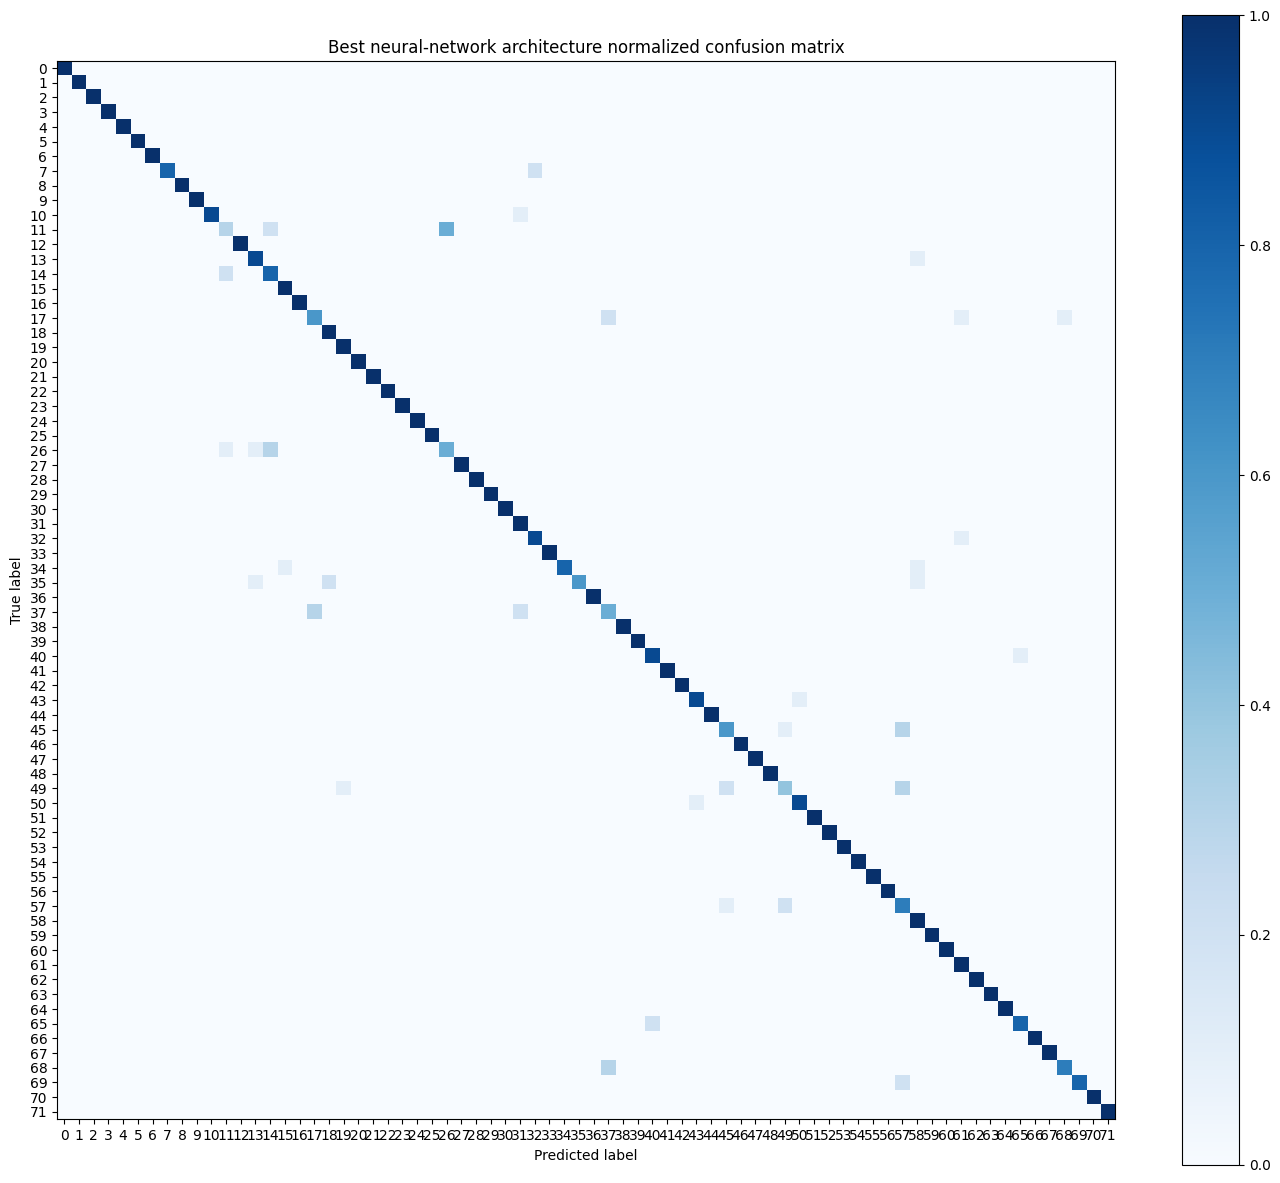

In [8]:
plot_df = architecture_results_df.set_index('Architecture')[['CV Accuracy Mean', 'Test Top-1', 'Test Top-5']]
ax = plot_df.plot(kind='bar', figsize=(10, 5), color=['#2E74B5', '#70AD47', '#FFC000'])
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Neural-network architecture comparison')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'neural_network_architecture_comparison.png'), dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_architecture_pred,
    normalize='true',
    include_values=False,
    cmap='Blues',
    ax=ax
)
ax.set_title('Best neural-network architecture normalized confusion matrix')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'neural_network_confusion_matrix.png'), dpi=180)
plt.show()
